<a href="https://colab.research.google.com/github/NafeesSayyed/Manufacturing-Defect-Discovery---Clustering-Association-Rules/blob/main/Manufacturing_Defect_Discovery_Clustering_Association_Rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('manufacturing_production_dataset.csv')

In [3]:
df.shape

(4000, 35)

In [4]:
df.head()

,Batch_ID,Operating_Temperature_C,Pressure_bar,Vibration_mm_s,Power_Consumption_kW,Material_Hardness_HRC,Humidity_pct,Cycle_Time_min,Machine_Age_Years,Production_Speed_units_hr,...,Thick_Material,Hard_Material,Old_Tool,Large_Batch,High_Humidity,Night_Shift,New_Operator,High_Workload,Defect,Defect_Type
0,1,71.18,NaN,1.60,96.22,62.74,41.05,46.50,4.12,745.1,...,0,0,0,0,0,0,0,0,1,Assembly Defect
1,2,74.61,113.07,1.14,73.01,61.00,45.63,42.08,6.81,744.5,...,0,0,0,0,0,0,0,0,0,No Defect
2,3,83.09,129.43,2.84,108.49,53.12,58.00,42.94,6.35,801.0,...,0,0,1,0,0,0,0,0,0,No Defect
3,4,82.44,106.05,3.97,76.60,49.12,48.83,55.40,6.71,863.0,...,0,0,0,1,0,0,0,1,0,No Defect
4,5,72.73,126.62,2.45,95.05,62.21,40.71,57.96,6.10,695.8,...,1,0,0,0,0,1,0,0,1,Assembly Defect


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Batch_ID                   4000 non-null   int64  
 1   Operating_Temperature_C    3938 non-null   float64
 2   Pressure_bar               3914 non-null   float64
 3   Vibration_mm_s             3914 non-null   float64
 4   Power_Consumption_kW       3935 non-null   float64
 5   Material_Hardness_HRC      3921 non-null   float64
 6   Humidity_pct               3918 non-null   float64
 7   Cycle_Time_min             3913 non-null   float64
 8   Machine_Age_Years          3930 non-null   float64
 9   Production_Speed_units_hr  3921 non-null   float64
 10  Material_Thickness_mm      3910 non-null   float64
 11  Tool_Age_hours             3918 non-null   float64
 12  Batch_Size_units           3925 non-null   float64
 13  Machine_Type               4000 non-null   objec

In [6]:
df.isnull().sum()

,0
Batch_ID,0
Operating_Temperature_C,62
Pressure_bar,86
Vibration_mm_s,86
Power_Consumption_kW,65
Material_Hardness_HRC,79
Humidity_pct,82
Cycle_Time_min,87
Machine_Age_Years,70
Production_Speed_units_hr,79


In [7]:
from sklearn.impute import SimpleImputer
cols = [
    'Operating_Temperature_C',
    'Pressure_bar',
    'Vibration_mm_s',
    'Power_Consumption_kW',
    'Material_Hardness_HRC',
    'Humidity_pct',
    'Cycle_Time_min',
    'Machine_Age_Years',
    'Production_Speed_units_hr',
    'Material_Thickness_mm',
    'Tool_Age_hours',
    'Batch_Size_units'
]
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
imputer.fit(df[cols])
df[cols] = imputer.transform(df[cols])

In [8]:
X = df.iloc[:, 1:13].values

In [9]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_scaled = sc_X.fit_transform(X)

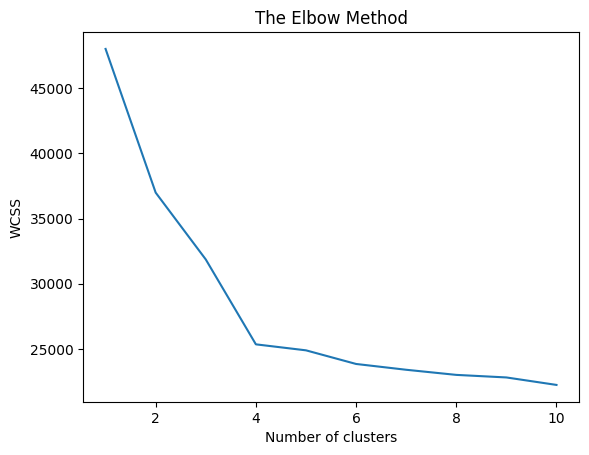

In [10]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

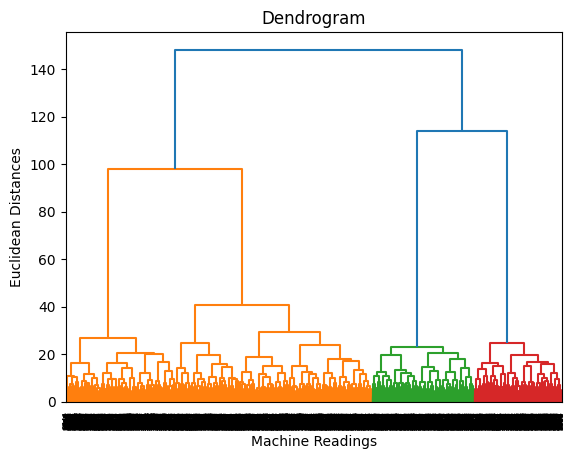

In [11]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Machine Readings')
plt.ylabel('Euclidean Distances')
plt.show()

### K-Means Clustering

K-Means clustering is applied to the standardized numerical production variables.
The Elbow Method and Dendrogram indicates that 4 clusters provide a suitable segmentation of the
production environments.

Each production record is assigned to one of four clusters (0–3), representing
different combinations of machine operating and production conditions.

In [12]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_scaled)

In [13]:
df['Cluster'] = y_kmeans
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,961
1,1514
2,701
3,824


In [14]:
cluster_defect = df.groupby("Cluster")["Defect"].mean()
print(cluster_defect * 100)

Cluster
0    21.436004
1     9.247028
2    44.935806
3    35.558252
Name: Defect, dtype: float64


### Cluster Defect Rate Analysis
 - Cluster 0: approximately 21.44% defective production
 - Cluster 1: approximately 9.25% defective production
 - Cluster 2: approximately 44.94% defective production
 - Cluster 3: approximately 35.56% defective production

In [15]:
categorical_cols = df.loc[:, 'Machine_Type' : 'Production_Line'].columns

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers = [('encoder', OneHotEncoder(handle_unknown = "ignore", sparse_output = False), categorical_cols)],
    remainder = "passthrough"
)
transformed_data = ct.fit_transform(df)
encoded_feature_names = ct.named_transformers_['encoder'].get_feature_names_out(categorical_cols)
passthrough_cols = [col for col in df.columns if col not in categorical_cols]
all_new_columns = list(encoded_feature_names) + passthrough_cols
df = pd.DataFrame(transformed_data, columns = all_new_columns, index = df.index)

In [17]:
clustering_cols = df.loc[:, 'Machine_Type_CNC':'Batch_Size_units'].columns

In [18]:
import pandas as pd
pd.set_option('display.max_columns', 40)

In [19]:
cluster_profile = df.groupby("Cluster")[clustering_cols].mean()
cluster_profile

,Machine_Type_CNC,Machine_Type_Injection_Molding,Machine_Type_Lathe,Machine_Type_Milling,Machine_Type_Press,Material_Type_Alloy,Material_Type_Aluminum,Material_Type_Composite,Material_Type_Plastic,Material_Type_Steel,Shift_Evening,Shift_Morning,Shift_Night,Operator_Experience_Experienced,Operator_Experience_Expert,Operator_Experience_Intermediate,Operator_Experience_New,Production_Line_Line_A,Production_Line_Line_B,Production_Line_Line_C,Production_Line_Line_D,Batch_ID,Operating_Temperature_C,Pressure_bar,Vibration_mm_s,Power_Consumption_kW,Material_Hardness_HRC,Humidity_pct,Cycle_Time_min,Machine_Age_Years,Production_Speed_units_hr,Material_Thickness_mm,Tool_Age_hours,Batch_Size_units
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.294485,0.16129,0.154006,0.181061,0.209157,0.243496,0.211238,0.144641,0.104058,0.296566,0.348595,0.437045,0.21436,0.380853,0.229969,0.255983,0.133195,0.265349,0.26743,0.258065,0.209157,1992.361082,77.208647,120.355338,3.043611,110.569417,61.196327,52.266087,42.188824,3.978398,824.809053,2.909594,1229.817534,466.396462
1,0.281374,0.174373,0.178996,0.199472,0.165786,0.238441,0.206737,0.120872,0.129458,0.304491,0.32959,0.433289,0.23712,0.356011,0.255614,0.26354,0.124835,0.291281,0.258256,0.235139,0.215324,2006.910172,72.377087,116.377223,2.291717,84.701004,60.455581,47.849095,48.478269,3.965621,735.380053,3.146744,908.514696,381.322325
2,0.293866,0.186876,0.172611,0.165478,0.18117,0.21398,0.229672,0.129815,0.116976,0.309558,0.39515,0.396576,0.208274,0.369472,0.258203,0.253923,0.118402,0.32525,0.238231,0.233951,0.202568,1987.49786,73.929929,113.14097,4.422496,97.893352,61.508688,55.129508,62.134636,11.056805,695.613409,3.206633,2147.58495,360.912981
3,0.234223,0.177184,0.203883,0.194175,0.190534,0.206311,0.184466,0.13835,0.131068,0.339806,0.320388,0.432039,0.247573,0.331311,0.260922,0.288835,0.118932,0.31432,0.239078,0.21966,0.226942,2009.275485,74.684527,128.671195,2.860267,116.60551,74.869575,49.25429,60.321129,5.560583,699.839684,4.279235,1789.331614,443.145631


### Cluster Profile Interpretation

The clusters represent different production environments based on the numerical
operating conditions used for K-Means clustering.

The categorical variables are used only for post-clustering profiling and are not
used to determine the cluster assignments.

Therefore, each cluster should be interpreted as a distinct combination of
operating temperature, pressure, vibration, power consumption, material properties,
humidity, cycle time, machine age, production speed, material thickness, tool age,
and batch size.

### Production Condition Profile of Clusters

The continuous production-condition variables are analyzed after clustering to
understand the characteristics of each cluster.

- **Cluster 0:** Characterized by the highest production speed and highest operating
  temperature, with moderately elevated power consumption.
- **Cluster 1:** Represents comparatively normal operating conditions, with the lowest
  vibration and lowest power consumption among all clusters.
- **Cluster 2:** Characterized by the oldest machines, highest vibration, longest cycle
  times, and highest tool age. These conditions occur consistently within this cluster.
- **Cluster 3:** Characterized by the highest pressure, highest power consumption,
  highest material hardness/thickness, and relatively high tool age.

These profiles help translate the numerical clusters into interpretable production
environments.

In [20]:
binary_cols = df.loc[:, 'Old_Machine':'High_Workload'].columns
cluster_conditions = df.groupby("Cluster")[binary_cols].mean()
cluster_conditions

,Old_Machine,High_Speed,High_Temperature,High_Pressure,High_Vibration,Long_Cycle,High_Power_Consumption,Thick_Material,Hard_Material,Old_Tool,Large_Batch,High_Humidity,Night_Shift,New_Operator,High_Workload
Cluster,,,,,,,,,,,,,,,
0,0.013528,0.579605,0.545265,0.291363,0.17794,0.003122,0.728408,0.043704,0.119667,0.007284,0.318418,0.049948,0.21436,0.133195,0.421436
1,0.005284,0.054161,0.081902,0.112946,0.013871,0.030383,0.027081,0.09247,0.101057,0.0,0.06605,0.008587,0.23712,0.124835,0.033025
2,0.89729,0.007133,0.221113,0.061341,0.850214,0.527817,0.28388,0.134094,0.138374,0.746077,0.031384,0.138374,0.208274,0.118402,0.002853
3,0.040049,0.007282,0.279126,0.743932,0.093447,0.459951,0.864078,0.872573,0.757282,0.273058,0.223301,0.01335,0.247573,0.118932,0.021845


In [21]:
clusters = {}

for i in range(4):
    cluster_df = df[df["Cluster"] == i].copy()
    cluster_df["Defect_Item"] = cluster_df["Defect_Type"].str.replace(" ", "_")
    clusters[f"cluster_{i}"] = cluster_df

cluster_0 = clusters["cluster_0"]
cluster_1 = clusters["cluster_1"]
cluster_2 = clusters["cluster_2"]
cluster_3 = clusters["cluster_3"]

In [22]:
apriori_data_0 = cluster_0[list(binary_cols) + ["Defect_Item"]].copy()
apriori_data_1 = cluster_1[list(binary_cols) + ["Defect_Item"]].copy()
apriori_data_2 = cluster_2[list(binary_cols) + ["Defect_Item"]].copy()
apriori_data_3 = cluster_3[list(binary_cols) + ["Defect_Item"]].copy()

### Transaction Construction

For Apriori, each production record is converted into a transaction containing the
binary production conditions that are present, together with its defect type.

This allows Apriori to discover recurring combinations of production conditions
associated with different defect types.

In [23]:
def build_transactions(cluster_df):
    transactions = []
    for _, row in cluster_df.iterrows():
        transaction = [
            col for col in binary_cols
            if row[col] == 1
        ]
        transaction.append(row["Defect_Item"])
        transactions.append(transaction)
    return transactions

transactions_0 = build_transactions(apriori_data_0)
transactions_1 = build_transactions(apriori_data_1)
transactions_2 = build_transactions(apriori_data_2)
transactions_3 = build_transactions(apriori_data_3)

In [24]:
transactions_0

[['High_Temperature',
  'High_Pressure',
  'High_Power_Consumption',
  'Old_Tool',
  'No_Defect'],
 ['High_Speed',
  'High_Temperature',
  'High_Vibration',
  'Large_Batch',
  'High_Workload',
  'No_Defect'],
 ['High_Speed',
  'High_Power_Consumption',
  'Night_Shift',
  'High_Workload',
  'No_Defect'],
 ['High_Temperature',
  'High_Pressure',
  'Hard_Material',
  'High_Humidity',
  'No_Defect'],
 ['High_Speed', 'High_Temperature', 'High_Power_Consumption', 'No_Defect'],
 ['High_Speed', 'High_Vibration', 'No_Defect'],
 ['Large_Batch', 'Night_Shift', 'High_Workload', 'No_Defect'],
 ['High_Speed',
  'High_Temperature',
  'High_Pressure',
  'High_Power_Consumption',
  'No_Defect'],
 ['High_Power_Consumption',
  'Large_Batch',
  'Night_Shift',
  'New_Operator',
  'No_Defect'],
 ['High_Workload', 'No_Defect'],
 ['High_Speed',
  'High_Temperature',
  'High_Vibration',
  'High_Power_Consumption',
  'Night_Shift',
  'No_Defect'],
 ['Old_Machine',
  'High_Power_Consumption',
  'Large_Batch',
  

In [25]:
transactions_1

[['Assembly_Defect'],
 ['No_Defect'],
 ['No_Defect'],
 ['No_Defect'],
 ['Night_Shift', 'No_Defect'],
 ['Thick_Material', 'No_Defect'],
 ['No_Defect'],
 ['No_Defect'],
 ['No_Defect'],
 ['High_Pressure', 'No_Defect'],
 ['No_Defect'],
 ['High_Temperature', 'New_Operator', 'No_Defect'],
 ['Night_Shift', 'No_Defect'],
 ['No_Defect'],
 ['Hard_Material', 'No_Defect'],
 ['Dimensional_Defect'],
 ['No_Defect'],
 ['No_Defect'],
 ['Long_Cycle', 'No_Defect'],
 ['Night_Shift', 'New_Operator', 'No_Defect'],
 ['Hard_Material', 'No_Defect'],
 ['No_Defect'],
 ['No_Defect'],
 ['Hard_Material', 'Structural_Defect'],
 ['New_Operator', 'No_Defect'],
 ['High_Temperature', 'New_Operator', 'No_Defect'],
 ['No_Defect'],
 ['High_Pressure', 'No_Defect'],
 ['No_Defect'],
 ['No_Defect'],
 ['No_Defect'],
 ['Night_Shift', 'Dimensional_Defect'],
 ['High_Pressure', 'Thick_Material', 'No_Defect'],
 ['No_Defect'],
 ['High_Speed', 'Thick_Material', 'Night_Shift', 'No_Defect'],
 ['No_Defect'],
 ['No_Defect'],
 ['No_Defect'

In [26]:
transactions_2

[['Old_Machine', 'High_Vibration', 'Long_Cycle', 'Old_Tool', 'No_Defect'],
 ['Old_Machine',
  'High_Vibration',
  'Hard_Material',
  'Old_Tool',
  'Surface_Defect'],
 ['Old_Machine',
  'High_Vibration',
  'Thick_Material',
  'Old_Tool',
  'Assembly_Defect'],
 ['Old_Machine',
  'High_Vibration',
  'High_Power_Consumption',
  'High_Humidity',
  'No_Defect'],
 ['Old_Machine', 'High_Vibration', 'High_Humidity', 'No_Defect'],
 ['High_Vibration', 'Long_Cycle', 'Old_Tool', 'No_Defect'],
 ['Old_Machine',
  'High_Vibration',
  'Long_Cycle',
  'High_Power_Consumption',
  'Hard_Material',
  'Old_Tool',
  'New_Operator',
  'Material_Defect'],
 ['Old_Machine', 'High_Vibration', 'Old_Tool', 'Surface_Defect'],
 ['Old_Machine',
  'High_Temperature',
  'High_Vibration',
  'High_Power_Consumption',
  'Old_Tool',
  'No_Defect'],
 ['Old_Machine',
  'High_Vibration',
  'Long_Cycle',
  'Thick_Material',
  'Old_Tool',
  'No_Defect'],
 ['Old_Machine',
  'High_Temperature',
  'High_Vibration',
  'Long_Cycle',


In [27]:
transactions_3

[['High_Pressure', 'Thick_Material', 'Night_Shift', 'Assembly_Defect'],
 ['High_Pressure',
  'Thick_Material',
  'Hard_Material',
  'Large_Batch',
  'Night_Shift',
  'No_Defect'],
 ['High_Temperature', 'High_Power_Consumption', 'Hard_Material', 'No_Defect'],
 ['High_Temperature',
  'High_Pressure',
  'High_Power_Consumption',
  'Thick_Material',
  'Large_Batch',
  'No_Defect'],
 ['High_Pressure',
  'High_Power_Consumption',
  'Thick_Material',
  'Hard_Material',
  'Old_Tool',
  'No_Defect'],
 ['High_Temperature',
  'High_Pressure',
  'High_Power_Consumption',
  'Thick_Material',
  'Hard_Material',
  'No_Defect'],
 ['High_Pressure',
  'Long_Cycle',
  'Hard_Material',
  'Old_Tool',
  'Material_Defect'],
 ['High_Pressure', 'Thick_Material', 'No_Defect'],
 ['High_Pressure',
  'Thick_Material',
  'Hard_Material',
  'Old_Tool',
  'Large_Batch',
  'No_Defect'],
 ['Long_Cycle',
  'Thick_Material',
  'Hard_Material',
  'Old_Tool',
  'Large_Batch',
  'Surface_Defect'],
 ['Long_Cycle', 'Thick_Mat

In [28]:
!pip install apyori

### Association Rule Mining Within Clusters

After identifying the production environments, each cluster is analyzed separately
using Apriori association rule mining.

The purpose is to identify combinations of production conditions that are associated
with specific defect types within each production environment.

This two-stage approach allows the analysis to answer:

1. What types of production environments exist?
2. Within each environment, which combinations of conditions are associated with
   particular defect types?

In [29]:
from apyori import apriori

def run_apriori(transactions, min_support=0.003, min_confidence=0.2, min_lift=1, min_length=3, max_length=5):
    rules = apriori(
        transactions=transactions,
        min_support=min_support,
        min_confidence=min_confidence,
        min_lift=min_lift,
        min_length=min_length,
        max_length=max_length
    )
    return list(rules)

results_0 = run_apriori(transactions_0)
results_1 = run_apriori(transactions_1)
results_2 = run_apriori(transactions_2)
results_3 = run_apriori(transactions_3)

In [30]:
def inspect_defect_type_rules(results):

    defect_types = {
        "Assembly_Defect",
        "Dimensional_Defect",
        "Material_Defect",
        "Structural_Defect",
        "Surface_Defect"
    }
    rows = []
    for result in results:
        for stat in result.ordered_statistics:
            lhs = set(stat.items_base)
            rhs = set(stat.items_add)

            if (
                len(lhs) > 0
                and len(rhs) == 1
                and next(iter(rhs)) in defect_types
            ):
                rows.append([
                    ", ".join(sorted(lhs)),
                    next(iter(rhs)),
                    result.support,
                    stat.confidence,
                    stat.lift
                ])

    return pd.DataFrame(
        rows,
        columns=[
            "Left Hand Side",
            "Right Hand Side",
            "Support",
            "Confidence",
            "Lift"
        ]
    )

In [31]:
df_results_0 = inspect_defect_type_rules(results_0)
df_results_1 = inspect_defect_type_rules(results_1)
df_results_2 = inspect_defect_type_rules(results_2)
df_results_3 = inspect_defect_type_rules(results_3)

In [32]:
df_results_0 = df_results_0.sort_values("Lift", ascending=False).reset_index(drop=True)
df_results_1 = df_results_1.sort_values("Lift", ascending=False).reset_index(drop=True)
df_results_2 = df_results_2.sort_values("Lift", ascending=False).reset_index(drop=True)
df_results_3 = df_results_3.sort_values("Lift", ascending=False).reset_index(drop=True)

### Cluster 0 — Association Rules

 **Cluster 0:** Characterized by the highest production speed and highest operating
  temperature, with moderately elevated power consumption.

Apriori identifies combinations of these operating conditions, along with factors
such as workload, new operators, night shifts and material conditions, that are
associated with Assembly, Material and Surface defects.

The rules provide condition combinations that can be investigated as potential
defect-associated production patterns within Cluster 0.

In [33]:
df_results_0.head(50)

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,"High_Speed, Large_Batch, New_Operator, Night_S...",Assembly_Defect,0.004162,0.571429,13.728571
1,"Hard_Material, High_Pressure, High_Speed, High...",Material_Defect,0.004162,0.500000,12.644737
2,"High_Speed, High_Temperature, New_Operator, Ni...",Assembly_Defect,0.003122,0.500000,12.012500
3,"High_Temperature, High_Workload, New_Operator,...",Assembly_Defect,0.003122,0.428571,10.296429
4,"High_Speed, High_Workload, New_Operator, Night...",Assembly_Defect,0.005203,0.416667,10.010417
5,"High_Workload, Large_Batch, New_Operator, Nigh...",Assembly_Defect,0.004162,0.363636,8.736364
6,"Hard_Material, High_Power_Consumption, High_Pr...",Material_Defect,0.005203,0.333333,8.429825
7,"High_Power_Consumption, Large_Batch, New_Opera...",Assembly_Defect,0.003122,0.333333,8.008333
8,"High_Temperature, Large_Batch, New_Operator, N...",Assembly_Defect,0.003122,0.333333,8.008333
9,"Hard_Material, High_Power_Consumption, High_Pr...",Material_Defect,0.004162,0.307692,7.781377


### Cluster 1 — Association Rules
**Cluster 1:** Represents comparatively normal operating conditions, with the lowest
  vibration and lowest power consumption among all clusters.

No defect-type association rules satisfying the selected Apriori thresholds were
identified for Cluster 1.

Cluster 1 has the lowest observed defect rate among the four clusters, which also
means that defect-type transactions are relatively limited compared with the other
clusters.

Therefore, no sufficiently strong defect-type rules were retained under the
selected support, confidence and lift thresholds.

In [34]:
df_results_1.head(30)

,Left Hand Side,Right Hand Side,Support,Confidence,Lift


### Cluster 2 — Association Rules

**Cluster 2:** Characterized by the oldest machines, highest vibration, longest cycle
  times, and highest tool age. These conditions occur consistently within this cluster.

Apriori identifies associations involving these conditions with Surface, Material,
Dimensional, Structural and Assembly defects.

Several rules show high confidence and lift, indicating recurring combinations of
production conditions associated with particular defect types within this cluster.

In [35]:
df_results_2.head(30)

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,"High_Pressure, High_Temperature, High_Vibratio...",Surface_Defect,0.004280,1.000000,5.890756
1,"High_Pressure, High_Temperature, Long_Cycle, O...",Surface_Defect,0.004280,1.000000,5.890756
2,"High_Pressure, High_Temperature, Long_Cycle, O...",Surface_Defect,0.004280,1.000000,5.890756
3,"High_Pressure, High_Temperature, Long_Cycle",Surface_Defect,0.004280,1.000000,5.890756
4,"High_Power_Consumption, High_Temperature, Old_...",Dimensional_Defect,0.004280,0.375000,5.593085
5,"Hard_Material, High_Temperature, High_Vibratio...",Structural_Defect,0.005706,0.500000,5.231343
6,"High_Power_Consumption, High_Temperature, Old_...",Dimensional_Defect,0.004280,0.333333,4.971631
7,"High_Power_Consumption, High_Temperature, Thic...",Dimensional_Defect,0.004280,0.333333,4.971631
8,"Hard_Material, High_Power_Consumption, Long_Cycle",Material_Defect,0.007133,0.312500,4.660904
9,"Hard_Material, High_Power_Consumption, High_Vi...",Material_Defect,0.007133,0.312500,4.660904


### Cluster 3 — Association Rules

**Cluster 3:** Characterized by the highest pressure, highest power consumption,
  highest material hardness/thickness, and relatively high tool age.

Apriori identifies associations with Surface, Assembly and Dimensional defects.

The rules highlight combinations such as high humidity, high pressure, high
temperature, long cycle time, old machines and material-related conditions that
are associated with particular defect types in this cluster.

In [36]:
df_results_3.head(30)

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,"High_Pressure, High_Temperature, Old_Machine, ...",Surface_Defect,0.003641,0.428571,9.054945
1,"High_Power_Consumption, Long_Cycle, Old_Machin...",Assembly_Defect,0.003641,0.333333,8.078431
2,"Hard_Material, High_Humidity",Surface_Defect,0.003641,0.375000,7.923077
3,"High_Power_Consumption, High_Pressure, High_Te...",Surface_Defect,0.003641,0.375000,7.923077
4,"High_Power_Consumption, High_Temperature, Old_...",Surface_Defect,0.003641,0.375000,7.923077
5,"Hard_Material, High_Humidity, Thick_Material",Surface_Defect,0.003641,0.375000,7.923077
6,"Hard_Material, High_Humidity, High_Power_Consu...",Surface_Defect,0.003641,0.375000,7.923077
7,"Hard_Material, High_Humidity, High_Power_Consu...",Surface_Defect,0.003641,0.375000,7.923077
8,"High_Pressure, High_Temperature, Old_Machine",Surface_Defect,0.003641,0.375000,7.923077
9,"High_Humidity, High_Power_Consumption, Thick_M...",Surface_Defect,0.004854,0.363636,7.682984


### Cluster 0 — Apriori Findings
**Cluster 0:** Characterized by the highest production speed and highest operating
  temperature, with moderately elevated power consumption.
  
Apriori identified several defect-associated production patterns within Cluster 0.

- **Assembly_Defect** was strongly associated with combinations involving New_Operator,
  Night_Shift, High_Speed, Large_Batch, and High_Workload.

- **Material_Defect** was repeatedly associated with Hard_Material combined with
  High_Pressure, High_Temperature, High_Speed, and/or High_Power_Consumption.

- **Dimensional_Defect** was associated with combinations of High_Pressure, High_Speed,
  High_Temperature, High_Vibration, and High_Workload.

- **Surface_Defect** showed associations involving High_Humidity, High_Power_Consumption,
  High_Speed, High_Pressure, and High_Temperature.

- A combination of **Night_Shift and Thick_Material** was associated with Structural_Defect.

These rules indicate recurring condition combinations within Cluster 0 that are
strongly associated with specific defect types. They represent associations rather
than causal relationships.

### Cluster 1 — Apriori Findings
**Cluster 1:** Represents comparatively normal operating conditions, with the lowest
  vibration and lowest power consumption among all clusters.
  
No association rules satisfying the selected Apriori thresholds were identified
for Cluster 1.

This cluster has the lowest observed defect rate among the four clusters
(approximately 9.25%). The absence of qualifying rules indicates that no
combination of production conditions met the selected minimum support,
confidence and lift criteria for association with a specific defect type.

Therefore, Cluster 1 does not provide sufficiently strong defect-type association
patterns under the current Apriori parameters.

### Cluster 2 — Apriori Findings (Defect_Type)
**Cluster 2:** Characterized by the oldest machines, highest vibration, longest cycle
  times, and highest tool age. These conditions occur consistently within this cluster.
  
Apriori identified several defect-associated production patterns within Cluster 2.

- **Surface_Defect** was the strongest signal in this cluster — several rules involving
  High_Pressure, High_Temperature, and Long_Cycle (with High_Vibration, Old_Machine, or
  Old_Tool) reached **100% confidence**.

- **Dimensional_Defect** was associated with combinations of High_Power_Consumption,
  High_Temperature, Thick_Material, and Old_Tool/Old_Machine.
- **Structural_Defect** was associated with Hard_Material combined with High_Temperature,
  High_Vibration, and Long_Cycle.

- **Material_Defect** was repeatedly associated with Hard_Material combined with
  High_Power_Consumption, Long_Cycle, High_Vibration, and/or Old_Machine/Old_Tool.

- **Assembly_Defect** showed associations involving High_Humidity, Night_Shift,
  Old_Machine, and Old_Tool.

These rules indicate recurring condition combinations within Cluster 2 that are
strongly associated with specific defect types. They represent associations rather
than causal relationships.

### Cluster 3 — Apriori Findings (Defect_Type)
**Cluster 3:** Characterized by the highest pressure, highest power consumption,
  highest material hardness/thickness, and relatively high tool age.
  
Apriori identified several defect-associated production patterns within Cluster 3.

- **Surface_Defect** was the dominant signal — strongly associated with High_Humidity,
  Hard_Material/Thick_Material, and High_Temperature combined with Old_Machine, High_Pressure,
  and/or High_Power_Consumption.

- **Assembly_Defect** was associated with Long_Cycle and Old_Machine, often together with
  High_Power_Consumption, High_Pressure, and Thick_Material.

- **Dimensional_Defect** was associated with High_Temperature and Large_Batch combined with
  Old_Tool, High_Pressure, Hard_Material, and/or High_Vibration.

These rules indicate recurring condition combinations within Cluster 3 that are
strongly associated with specific defect types. They represent associations rather
than causal relationships.